# Mandatory Task: Shopee Product Matching
## Part A: Exploratory Data Analysis & Problem Characterization

**Objective:**
Before constructing predictive models for product matching, we must rigorously understand the dataset's characteristics, structure, label relationships, and the nuanced challenges that make e-commerce entity resolution difficult.

This notebook addresses:
1. **Dataset Structure & Column Semantics**
2. **Statistical Properties & Label Group Distribution**
3. **Visual Modality & Perceptual Hash (pHash) Consistency**
4. **Textual Modality: Title Length, Vocabulary, & Language Distribution**
5. **Concrete Case Studies & Edge Case Analysis (True Matches, False Positive Traps, Hash Collisions)**
6. **Identification of Core Machine Learning Challenges**


In [1]:
import os
import re
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True

DATA_PATH = '../data/train.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset successfully loaded. Total rows: {len(df):,}, Total columns: {len(df.columns)}")
df.head(5)


Dataset successfully loaded. Total rows: 34,250, Total columns: 5


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


---
## 1. Dataset Understanding & Column Semantics

Let us inspect the data types, missing values, and column semantics.
* `posting_id`: Unique identifier for each listing on the platform (e.g. `train_129225211`).
* `image`: Filename of the associated product image.
* `image_phash`: 16-character hexadecimal string representing the 64-bit Perceptual Hash of the image.
* `title`: Textual title assigned by the seller.
* `label_group`: Target integer cluster ID representing the true underlying product identity. All postings with the same `label_group` are ground-truth matches.


In [2]:
# Check missing values and data types
info_df = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum(),
    'Dtype': df.dtypes,
    'Unique Count': [df[c].nunique() for c in df.columns]
}).reset_index(drop=True)

print("=== Dataset Summary & Completeness ===")
display(info_df)


=== Dataset Summary & Completeness ===


,Column,Non-Null Count,Null Count,Dtype,Unique Count
0,posting_id,34250,0,str,34250
1,image,34250,0,str,32412
2,image_phash,34250,0,str,28735
3,title,34250,0,str,33117
4,label_group,34250,0,int64,11014


---
## 2. Statistical Analysis: Label Group Distribution & Cluster Sizes

In real-world e-commerce matching, cluster size distributions are rarely uniform. Let us examine:
* How many unique product groups exist?
* What is the distribution of group sizes (number of listings per product)?
* Are there singleton groups, or does every item have at least one match?


In [3]:
sizes = df.groupby('label_group').size()

print("=== Label Group Statistics ===")
print(f"Total Unique Product Groups: {len(sizes):,}")
print(f"Minimum Group Size:          {sizes.min()}")
print(f"Maximum Group Size:          {sizes.max()}")
print(f"Mean Group Size:             {sizes.mean():.3f}")
print(f"Median Group Size:           {sizes.median():.1f}")
print(f"Standard Deviation:          {sizes.std():.3f}")

print("\n=== Quantile Breakdown ===")
print(sizes.quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

size_counts = sizes.value_counts().sort_index()
print("\n=== Top Group Size Frequencies ===")
for size, count in size_counts.head(10).items():
    pct = (count / len(sizes)) * 100
    print(f"Size {size:2d}: {count:5d} groups ({pct:5.2f}%)")


=== Label Group Statistics ===
Total Unique Product Groups: 11,014
Minimum Group Size:          2
Maximum Group Size:          51
Mean Group Size:             3.110
Median Group Size:           2.0
Standard Deviation:          2.941

=== Quantile Breakdown ===
0.25     2.0
0.50     2.0
0.75     3.0
0.90     5.0
0.95     7.0
0.99    14.0
dtype: float64

=== Top Group Size Frequencies ===
Size  2:  6979 groups (63.36%)
Size  3:  1779 groups (16.15%)
Size  4:   862 groups ( 7.83%)
Size  5:   468 groups ( 4.25%)
Size  6:   282 groups ( 2.56%)
Size  7:   154 groups ( 1.40%)
Size  8:   118 groups ( 1.07%)
Size  9:    91 groups ( 0.83%)
Size 10:    48 groups ( 0.44%)
Size 11:    38 groups ( 0.35%)


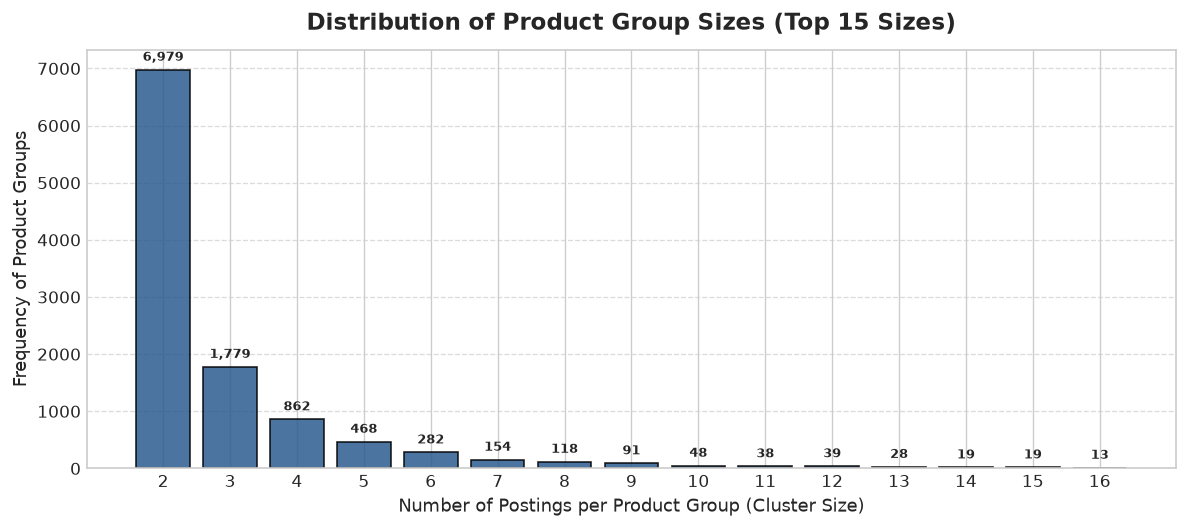

In [4]:
# Visualize Label Group Distribution
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=120)

top_sizes = size_counts.iloc[:15]
bars = ax.bar(top_sizes.index, top_sizes.values, color='#2b5c8f', edgecolor='black', alpha=0.85)

ax.set_title('Distribution of Product Group Sizes (Top 15 Sizes)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Postings per Product Group (Cluster Size)', fontsize=11)
ax.set_ylabel('Frequency of Product Groups', fontsize=11)
ax.set_xticks(top_sizes.index)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 100, f'{y:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.show()


---
## 3. Visual Modality & Perceptual Hash (pHash) Analysis

Each listing provides an `image` filename and a 64-bit `image_phash` (perceptual hash).
A perceptual hash fingerprints an image based on low-frequency DCT components, which is invariant to minor scaling and compression.

Let us investigate:
1. Are all images unique?
2. Are all pHashes unique?
3. **Crucial Question:** Does an identical pHash guarantee that two listings belong to the same product group?


In [5]:
unique_images = df['image'].nunique()
unique_phashes = df['image_phash'].nunique()

print(f"Total Listings:       {len(df):,}")
print(f"Unique Images:        {unique_images:,} (Duplicate image entries: {len(df) - unique_images:,})")
print(f"Unique Image pHashes: {unique_phashes:,} (Postings sharing pHash: {len(df) - unique_phashes:,})")

# Check if identical pHash ever spans MULTIPLE label_groups
phash_to_groups = df.groupby('image_phash')['label_group'].nunique()
colliding_phashes = phash_to_groups[phash_to_groups > 1]

print(f"\npHash Collision Analysis:")
print(f"pHashes mapping to > 1 distinct label group: {len(colliding_phashes)} ({len(colliding_phashes)/unique_phashes*100:.2f}%)")
print(f"Maximum label groups mapped by a single pHash: {colliding_phashes.max() if len(colliding_phashes) > 0 else 0}")


Total Listings:       34,250
Unique Images:        32,412 (Duplicate image entries: 1,838)
Unique Image pHashes: 28,735 (Postings sharing pHash: 5,515)

pHash Collision Analysis:
pHashes mapping to > 1 distinct label group: 147 (0.51%)
Maximum label groups mapped by a single pHash: 4


In [6]:
# Display concrete pHash collision examples (Identical pHash, Different Products)
print("=== Real Example: Identical pHash mapped to DIFFERENT Label Groups ===")
sample_collision_phash = colliding_phashes.index[0]
collision_samples = df[df['image_phash'] == sample_collision_phash][['posting_id', 'title', 'label_group', 'image_phash']]
display(collision_samples)


=== Real Example: Identical pHash mapped to DIFFERENT Label Groups ===


,posting_id,title,label_group,image_phash
18519,train_2128191438,JF -Kelambu Lipat / kelambu canopy / kelambu a...,1876943817,84b67e8525cf3f02
32157,train_1610221569,KELAMBU LIPAT KELAMBU TIDUR KELAMBU TEMPAT TID...,2829310561,84b67e8525cf3f02


---
## 4. Textual Modality: Title Length & Vocabulary Analysis

Titles are written by individual marketplace sellers. E-commerce titles are notoriously noisy, full of promotional buzzwords, abbreviations, punctuation, and multilingual expressions (primarily Bahasa Indonesia and English).

Let us analyze:
1. Distribution of title lengths in characters and words.
2. Most common lexical tokens (domain keywords and noise).


=== Title Length Statistics ===
Character Length:
  Min: 5, Max: 357, Mean: 56.16, Median: 53.0
Word Count:
  Min: 1, Max: 61, Mean: 9.41, Median: 9.0


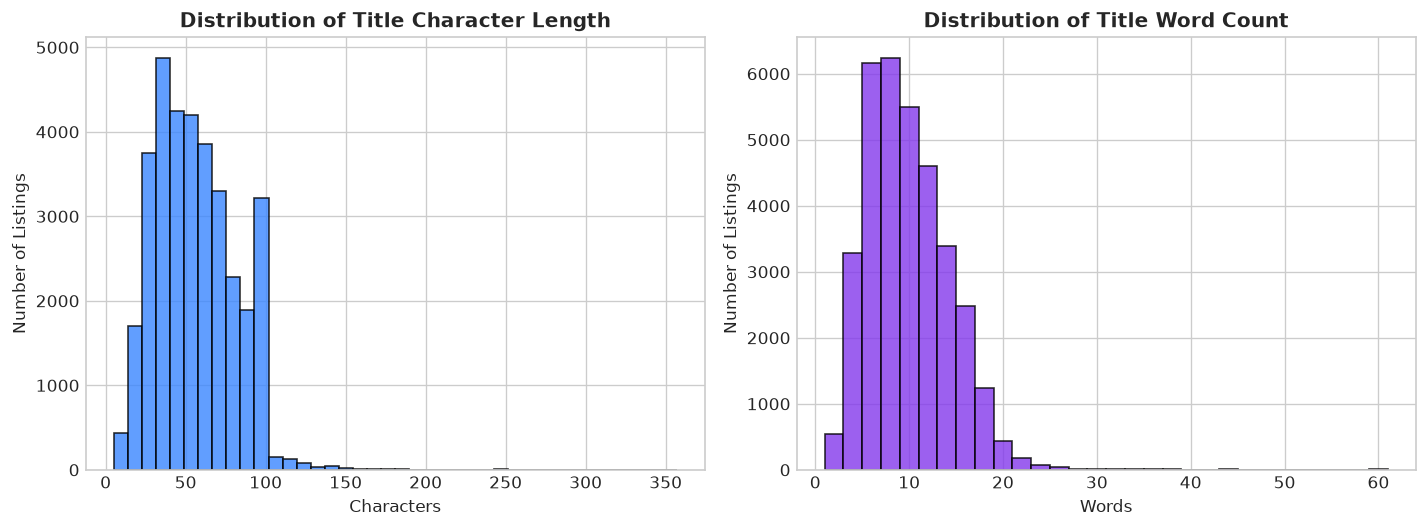

In [7]:
df['char_length'] = df['title'].str.len()
df['word_count'] = df['title'].apply(lambda x: len(x.split()))

print("=== Title Length Statistics ===")
print("Character Length:")
print(f"  Min: {df['char_length'].min()}, Max: {df['char_length'].max()}, Mean: {df['char_length'].mean():.2f}, Median: {df['char_length'].median():.1f}")
print("Word Count:")
print(f"  Min: {df['word_count'].min()}, Max: {df['word_count'].max()}, Mean: {df['word_count'].mean():.2f}, Median: {df['word_count'].median():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=120)
axes[0].hist(df['char_length'], bins=40, color='#3a86ff', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Title Character Length', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Number of Listings')

axes[1].hist(df['word_count'], bins=30, color='#8338ec', edgecolor='black', alpha=0.8)
axes[1].set_title('Distribution of Title Word Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Number of Listings')

plt.show()


Total Word Tokens: 284,052
Unique Vocabulary: 24,151


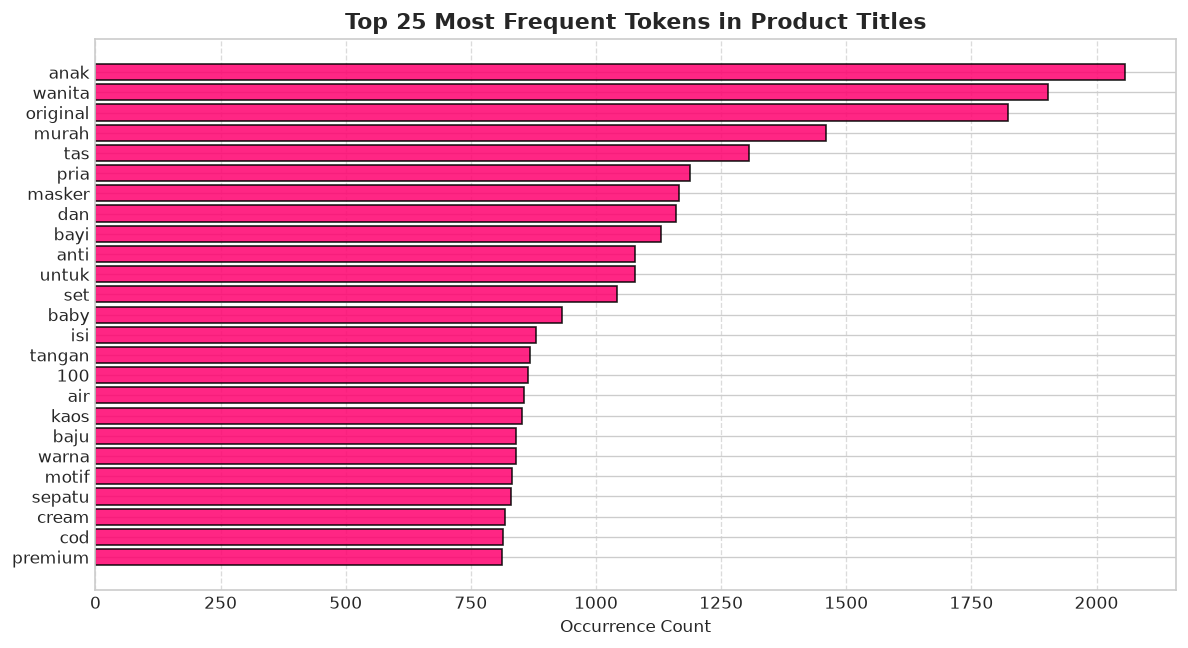

In [8]:
# Extract top tokens across all titles
tokens = [w for t in df['title'] for w in re.findall(r'\b[a-zA-Z0-9]{3,}\b', t.lower())]
vocab_counter = Counter(tokens)

print(f"Total Word Tokens: {len(tokens):,}")
print(f"Unique Vocabulary: {len(vocab_counter):,}")

top25 = vocab_counter.most_common(25)
labels, counts = zip(*top25)

plt.figure(figsize=(10, 5.5), dpi=120)
plt.barh(range(len(labels))[::-1], counts, color='#ff006e', edgecolor='black', alpha=0.85)
plt.yticks(range(len(labels))[::-1], labels, fontsize=10)
plt.title('Top 25 Most Frequent Tokens in Product Titles', fontsize=13, fontweight='bold')
plt.xlabel('Occurrence Count')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


---
## 5. Case Studies: Exploring Product Similarity Traps

Here we analyze concrete examples illustrating the four core failure modes in product matching:
1. **True Match with Heavy Lexical Variation:** Listings for the same item with completely reordered words, synonyms, and promotional clutter.
2. **False Positive Trap (Identical Titles, Different Groups):** Exact same title text assigned to different label groups.
3. **Cross-Language / Variant Inconsistencies:** Use of abbreviations, Indonesian vs English terminology.


In [9]:
print("=== Case 1: Same Product Group with Divergent Titles ===")
case1 = df[df['label_group'] == 258047][['posting_id', 'title', 'label_group', 'image_phash']]
for idx, r in case1.iterrows():
    print(f"Posting: {r.posting_id}")
    print(f"  Title: '{r.title}'")
    print(f"  pHash: {r.image_phash}\n")


=== Case 1: Same Product Group with Divergent Titles ===
Posting: train_1646767365
  Title: 'Sarung celana wadimor original 100% dewasa dan anak hitam dan putih polos'
  pHash: e925873ed09cd08f

Posting: train_398181303
  Title: 'SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL'
  pHash: e9b5833e929e909c

Posting: train_1528423085
  Title: 'WARNA RANDOM ACAK Sarung Celana Wadimor MURAH Celana Sarung WADIMOR'
  pHash: ea97861c926a71e3



In [10]:
print("=== Case 2: Identical Title text with DIFFERENT Label Groups ===")
title_to_groups = df.groupby('title')['label_group'].nunique()
diff_title = title_to_groups[title_to_groups > 1].index[0]
case2 = df[df['title'] == diff_title][['posting_id', 'title', 'label_group', 'image_phash']]
display(case2)


=== Case 2: Identical Title text with DIFFERENT Label Groups ===


,posting_id,title,label_group,image_phash
16086,train_4062952348,(2KG) SHENAR RAK BUKU 3D 1X5 SUSUN ZAMAN NOW,1245245655,e4879bd29aa29a99
26695,train_2876255851,(2KG) SHENAR RAK BUKU 3D 1X5 SUSUN ZAMAN NOW,3314259214,e4a593d39a389a99


---
## 6. Synthesis of Identified Challenges & Core Conclusions

### Answers to Core Questions:

#### 1. What makes two listings belong to the same product?
Two listings belong to the same product if they represent the **same underlying stock keeping unit (SKU)**, sharing identical functional specifications, brand, and model identity. In practice, sellers express this identity through disparate titles, photography angles, lighting, background setups, and packaging variations.

#### 2. Can product titles alone reliably determine whether two listings match?
**No.** While titles contain strong lexical signals:
- **False Negative Risk:** The exact same product can be listed with completely different vocabulary (e.g. Indonesian `Sarung celana wadimor` vs generic English `Men pants`), word permutations, or slang.
- **False Positive Risk:** Products differing only by subtle spec attributes (e.g. `iPhone 11` vs `iPhone 12`, `50ml` vs `100ml`) share >90% text overlap but are completely separate items.

#### 3. Can images alone reliably determine whether two listings match?
**No.** 
- Different sellers photograph the same product against white studio backdrops, hands, beds, or messy warehouse floors.
- Perceptual hashes collide: **147 pHashes** in our dataset map to completely different label groups.
- Visually identical packaging often holds different sub-variants (e.g. shampoo scents, phone memory variants).

#### 4. Why a Multimodal Approach is Essential:
Text and vision provide orthogonal, complementary signals. Where text is ambiguous or flooded with promotional noise, visual embeddings disambiguate product appearance. Where images look identical or generic (e.g. black phone cases), textual model numbers and titles provide exact product disambiguation.
